In [7]:
import pandas as pd #Allahın belası DataFrame'i jupyter'de daha güzel gözüküyormuş. 
import numpy as np 

In [8]:
np.random.seed(42) #Gruptaki herkesin aynı rastgele değerleri görmesi için.

In [9]:
import sqlite3
import pandas as pd

# 1. Veritabanına bağlantı aç
conn = sqlite3.connect('db.sqlite3')

# 2. SQL Sorgusunu Hazırla (Tarih olmadığı için sadece Ders ve Süre'yi çekiyoruz)
sorgu = """
    SELECT 
        c.name AS Ders, 
        fs.duration AS "Odaklanma Süresi"
    FROM FocusSession fs
    JOIN Category c ON fs.category_id = c.id
"""

# 3. Pandas ile sorguyu çalıştır ve DataFrame (df) oluştur
df = pd.read_sql_query(sorgu, conn)

# 4. Veritabanı bağlantısını kapat
conn.close()

print("🚀 Gerçek veritabanından veriler başarıyla çekildi!")
display(df.head())

🚀 Gerçek veritabanından veriler başarıyla çekildi!


,Ders,Odaklanma Süresi
0,C++,2.5
1,Python,1.5
2,C++,3.0
3,Matematik,4.0
4,C++,2.5


In [10]:
# dersler= ["Matematik", "Türkçe", "Fizik", "Kimya", "Biyoloji", "Tarih", "Coğrafya", "Felsefe", "Din" ]

# data= {
#     "Tarih" : pd.date_range(start="01.03.2026", periods=7), # Periyotun aylık olmasından ziyade haftalık olmasının çalışma analizi bakımından daha faydalı olduğunu düşünüyorum.
#     "Ders" : np.random.choice(dersler, 7),
#     "Odaklanma Süresi" : np.random.randint(25,200,7), #Bir çalışma periyotunu 25 dk aldım, en fazla 8 tane yapılabilir. 
#     "Mola" : np.random.randint(5,15,7)
# }

# df = pd.DataFrame(data)
# df.head()


In [11]:
ders_analiz= df.groupby("Ders")["Odaklanma Süresi"].sum().sort_values(ascending=False) #En fazla çalışılan dersten en az çalışılan derse göre bir sıralama.
print("Derslere kaç dakika çalışmışım?")
print(ders_analiz)
en_verimli = ders_analiz .idxmax() #.idxmax() komutu ile en çok çalışılan dersi buldum.
print(f"\nEn verimli ders: {en_verimli}")




Derslere kaç dakika çalışmışım?
Ders
C++          11.0
Matematik     8.0
Python        3.0
Name: Odaklanma Süresi, dtype: float64

En verimli ders: C++


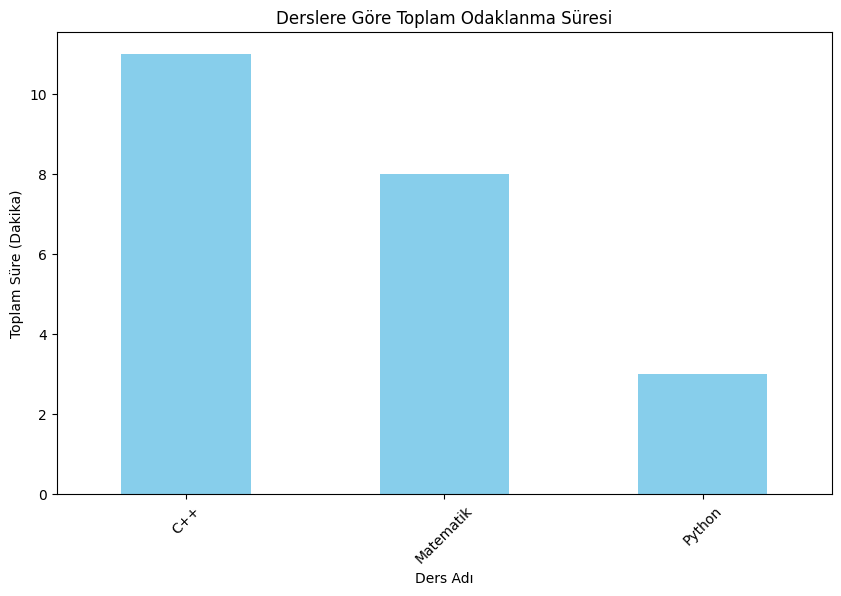

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
ders_analiz.plot(kind="bar", color="skyblue")
plt.title('Derslere Göre Toplam Odaklanma Süresi')
plt.xlabel('Ders Adı')
plt.ylabel('Toplam Süre (Dakika)')
plt.xticks(rotation=45)
plt.show() # Burası içime sinmedi daha güzel olabilir. 

In [13]:
df.to_csv('monkmode_analiz_verisi.csv', index=False)
print("Veriler 'monkmode_analiz_verisi.csv' olarak kaydedildi.")

Veriler 'monkmode_analiz_verisi.csv' olarak kaydedildi.


In [14]:
def hesapla_ekstra_metrikler(df, gecen_hafta_toplam=750): 
    toplam_sure = int(df["Odaklanma Süresi"].sum())
    ortalama_seans = float(df["Odaklanma Süresi"].mean())

    fark = toplam_sure - gecen_hafta_toplam
    degisim_yuzdesi = (fark / gecen_hafta_toplam) * 100

    #Geçen haftaya göre bu hafta yüzde kaç verimliyiz?
    
    # En çok çalışılan 3 ders
    en_cok_3 = df.groupby("Ders")["Odaklanma Süresi"].sum().nlargest(3).to_dict()
    
    return {
        "toplam_sure": toplam_sure,
        "ortalama_seans": round(ortalama_seans, 2),
        "degisim_yuzdesi": round(degisim_yuzdesi, 2),
        "en_cok_3": en_cok_3
    }

metrikler = hesapla_ekstra_metrikler(df)

In [15]:
import json

def frontend_icin_json_hazirla(metrikler):
    frontend_yapisi = {
        "ozet_istatistikler": {
            "toplamOdaklanma": metrikler["toplam_sure"],
            "ortalamaOturum": metrikler["ortalama_seans"],
            "haftalikDegisim": metrikler["degisim_yuzdesi"]
        },
        "grafik_verisi": [
            {"ders_adi": ders, "dakika": sure} 
            for ders, sure in metrikler["en_cok_3"].items()
        ]
    }
    return json.dumps(frontend_yapisi, ensure_ascii=False, indent=4)

print(frontend_icin_json_hazirla(metrikler))

{
    "ozet_istatistikler": {
        "toplamOdaklanma": 22,
        "ortalamaOturum": 2.75,
        "haftalikDegisim": -97.07
    },
    "grafik_verisi": [
        {
            "ders_adi": "C++",
            "dakika": 11.0
        },
        {
            "ders_adi": "Matematik",
            "dakika": 8.0
        },
        {
            "ders_adi": "Python",
            "dakika": 3.0
        }
    ]
}


In [16]:
def ai_ozeti_uret(metrikler):
    en_cok_ders = list(metrikler["en_cok_3"].keys())[0]
    durum = "artış" if metrikler["degisim_yuzdesi"] > 0 else "azalış"
    
    ozet = (
        f"Bu hafta toplam {metrikler['toplam_sure']} dakika odaklandın. "
        f"En çok vakit ayırdığın ders {en_cok_ders} oldu. "
        f"Geçen haftaya göre odaklanma performansında %{abs(metrikler['degisim_yuzdesi'])} oranında bir {durum} gözlemlendi."
    )
    return ozet

print(ai_ozeti_uret(metrikler))

Bu hafta toplam 22 dakika odaklandın. En çok vakit ayırdığın ders C++ oldu. Geçen haftaya göre odaklanma performansında %97.07 oranında bir azalış gözlemlendi.


In [17]:
import pandas as pd
import numpy as np
import json

def dinamik_verimlilik_motoru(df):
   
    # Derslere göre grupla ve süreleri topla
    kategori_analizi = df.groupby("Ders")["Odaklanma Süresi"].sum()
    
    # En yüksek süreye sahip dersin adını bul
    en_verimli_ders = kategori_analizi.idxmax()
    
    # O derse ait toplam dakikayı al
    toplam_dakika = int(kategori_analizi.max())
    
    return {
        "kategori": en_verimli_ders,
        "toplam_sure": toplam_dakika
    }


def veri_paketi(df, aktif_seri=7):
   
    # En güncel tarihi bul (Tablodaki son gün)
    en_guncel_tarih = df["Tarih"].max()
    
    # Sadece en güncel tarihe ait satırları filtrele
    bugunku_kayitlar = df[df["Tarih"] == en_guncel_tarih]
    
    # Gerekli metrikleri hesapla
    gunluk_toplam = int(bugunku_kayitlar["Odaklanma Süresi"].sum())
    
    # Günün en son kaydındaki dersi al (.iloc[-1] son satırı getirir)
    en_son_ders = bugunku_kayitlar.iloc[-1]["Ders"] 
    
    # JSON paketi
    JSON_paketi = {
        "metadata": {
            "tarih": en_guncel_tarih.strftime("%Y-%m-%d"),
            "karakter": "Acımasız Start-up Koçu"
        },
        "performans_verileri": {
            "gunluk_toplam_dakika": gunluk_toplam,
            "en_son_calisilan_konu": en_son_ders,
            "aktif_streak_gunu": aktif_seri
        }
    }
    
    # JSON string olarak döndür (ensure_ascii=False ile Türkçe karakter desteği sağlanır)
    return json.dumps(JSON_paketi, ensure_ascii=False, indent=4)


# Bi test yapalım

verimlilik_sonucu = dinamik_verimlilik_motoru(df)
print("--- 1. GÖREV: Dashboard Verisi ---")
print(f"En Verimli Kategori: {verimlilik_sonucu['kategori']}")
print(f"Toplam Harcanan Mesai: {verimlilik_sonucu['toplam_sure']} dakika\n")


girdi_verisi = veri_paketi(df, aktif_seri=7)
print("JSON veri çıktısı")
print(girdi_verisi)

--- 1. GÖREV: Dashboard Verisi ---
En Verimli Kategori: C++
Toplam Harcanan Mesai: 11 dakika



KeyError: 'Tarih'

In [ ]:
# import sqlite3
# import pandas as pd

# # Veritabanına bağlan
# conn = sqlite3.connect('db.sqlite3')

# # FocusSession tablosunun "röntgenini" (hangi sütunlara sahip olduğunu) çek
# sutunlar = pd.read_sql_query("PRAGMA table_info(FocusSession);", conn)

# print("FocusSession Tablosundaki Gerçek Sütunlar:")
# display(sutunlar)

# # Bağlantıyı kapat
# conn.close()

FocusSession Tablosundaki Gerçek Sütunlar:


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,duration,REAL,0,None,0
2,2,category_id,INTEGER,0,None,0
